In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
file_path = "../dataset/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (541909, 8)


In [3]:
print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset Shape:
(541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
InvoiceNo,0,0.000000
StockCode,0,0.000000
Description,1454,0.268311
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
CustomerID,135080,24.926694
Country,0,0.000000


In [6]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 5268


In [7]:
df = df.drop_duplicates()

print("Duplicate records removed successfully!")
print("Dataset shape after removing duplicates:", df.shape)

Duplicate records removed successfully!
Dataset shape after removing duplicates: (536641, 8)


In [8]:
cancelled_count = df['InvoiceNo'].astype(str).str.startswith('C').sum()

print("Cancelled transactions:", cancelled_count)

Cancelled transactions: 9251


In [9]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print("Cancelled transactions removed successfully!")
print("Dataset shape after removing cancelled transactions:", df.shape)

Cancelled transactions removed successfully!
Dataset shape after removing cancelled transactions: (527390, 8)


In [10]:
print("Negative/zero Quantity:", (df['Quantity'] <= 0).sum())
print("Zero/negative UnitPrice:", (df['UnitPrice'] <= 0).sum())

Negative/zero Quantity: 1336
Zero/negative UnitPrice: 2512


In [12]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print("Invalid Quantity and UnitPrice records removed successfully!")
print("Dataset shape after cleaning:", df.shape)

Invalid Quantity and UnitPrice records removed successfully!
Dataset shape after cleaning: (524878, 8)


In [13]:
print("Minimum Quantity:", df['Quantity'].min())
print("Minimum UnitPrice:", df['UnitPrice'].min())

Minimum Quantity: 1
Minimum UnitPrice: 0.001


In [14]:
print("Missing CustomerID before cleaning:",
      df['CustomerID'].isnull().sum())

Missing CustomerID before cleaning: 132186


In [15]:
df = df.dropna(subset=['CustomerID'])

print("Missing CustomerID records removed successfully!")
print("Missing CustomerID after cleaning:",
      df['CustomerID'].isnull().sum())
print("Dataset shape after CustomerID cleaning:", df.shape)

Missing CustomerID records removed successfully!
Missing CustomerID after cleaning: 0
Dataset shape after CustomerID cleaning: (392692, 8)


In [16]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("TotalPrice calculated successfully!")

display(df[['Quantity', 'UnitPrice', 'TotalPrice']].head())

TotalPrice calculated successfully!


,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [17]:
customer_summary = df.groupby('CustomerID').agg(
    Purchase_Frequency=('InvoiceNo', 'nunique'),
    Purchase_Value=('TotalPrice', 'sum'),
    Total_Quantity=('Quantity', 'sum')
)

customer_summary.head()

,Purchase_Frequency,Purchase_Value,Total_Quantity
CustomerID,,,
12346.0,1,77183.60,74215
12347.0,7,4310.00,2458
12348.0,4,1797.24,2341
12349.0,1,1757.55,631
12350.0,1,334.40,197


In [18]:
customer_summary['Average_Purchase_Value'] = (
    customer_summary['Purchase_Value'] /
    customer_summary['Purchase_Frequency']
)

customer_summary.head()

,Purchase_Frequency,Purchase_Value,Total_Quantity,Average_Purchase_Value
CustomerID,,,,
12346.0,1,77183.60,74215,77183.600000
12347.0,7,4310.00,2458,615.714286
12348.0,4,1797.24,2341,449.310000
12349.0,1,1757.55,631,1757.550000
12350.0,1,334.40,197,334.400000


In [19]:
print("Number of customers:", len(customer_summary))

print("\nCustomer Summary Statistics:")
display(customer_summary.describe())

Number of customers: 4338

Customer Summary Statistics:


,Purchase_Frequency,Purchase_Value,Total_Quantity,Average_Purchase_Value
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,4.272015,2048.688081,1187.644537,417.645735
std,7.697998,8985.230220,5043.619654,1796.511343
min,1.000000,3.750000,1.000000,3.450000
25%,1.000000,306.482500,159.000000,177.867083
50%,2.000000,668.570000,378.000000,291.940000
75%,5.000000,1660.597500,989.750000,428.280625
max,209.000000,280206.020000,196915.000000,84236.250000


In [20]:
print("Latest transaction date:")
print(df['InvoiceDate'].max())

print("\nEarliest transaction date:")
print(df['InvoiceDate'].min())

Latest transaction date:
2011-12-09 12:50:00

Earliest transaction date:
2010-12-01 08:26:00


In [21]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [22]:
print("RFM analysis completed successfully!")
print("Number of customers:", len(rfm))

display(rfm.describe())

RFM analysis completed successfully!
Number of customers: 4338


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [23]:
# Select behavioral features for clustering

clustering_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

print("Selected clustering features:")
print(clustering_features.columns.tolist())

display(clustering_features.head())

Selected clustering features:
['Recency', 'Frequency', 'Monetary']


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(clustering_features)

scaled_features = pd.DataFrame(
    scaled_features,
    columns=clustering_features.columns,
    index=clustering_features.index
)

print("Features standardized successfully!")

display(scaled_features.head())

Features standardized successfully!


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


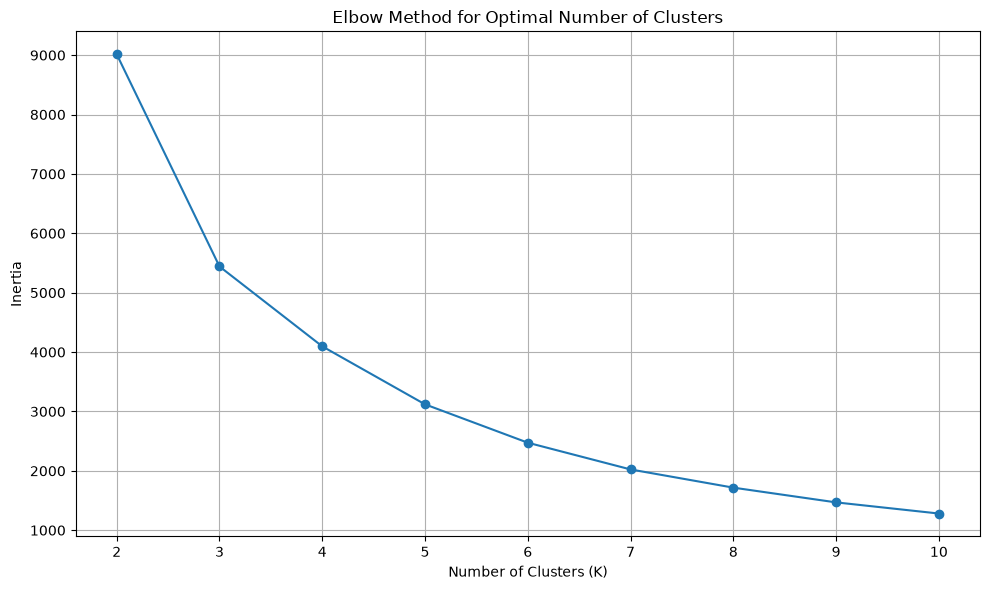

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(K_range, inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()

plt.show()

In [26]:
# Apply K-Means clustering with 4 customer segments

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(scaled_features)

print("K-Means clustering completed successfully!")
print("Number of clusters:", rfm['Cluster'].nunique())

display(rfm.head())

K-Means clustering completed successfully!
Number of clusters: 4


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [27]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

print("Number of customers in each cluster:")
display(cluster_counts)

Number of customers in each cluster:


Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

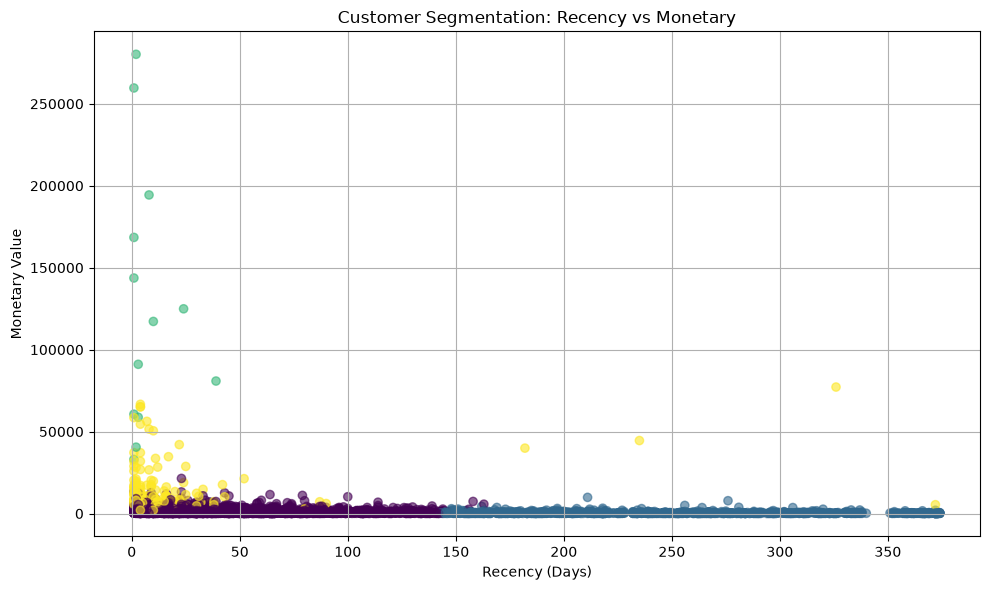

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    alpha=0.6
)

plt.title('Customer Segmentation: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.grid(True)
plt.tight_layout()

plt.show()

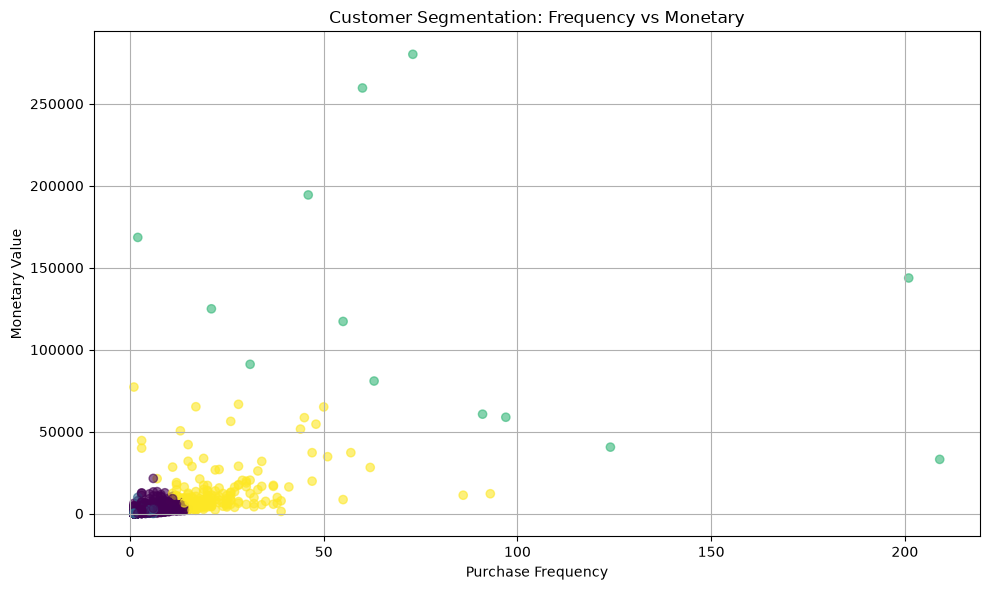

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    alpha=0.6
)

plt.title('Customer Segmentation: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.grid(True)
plt.tight_layout()

plt.show()

In [30]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_profile = cluster_profile.round(2)

print("Customer Cluster Profile:")
display(cluster_profile)

Customer Cluster Profile:


,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [31]:
cluster_profile['Customer_Count'] = rfm['Cluster'].value_counts().sort_index()

cluster_profile

,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,43.70,3.68,1353.63,3054
1,248.08,1.55,478.85,1067
2,7.38,82.54,127187.96,13
3,15.50,22.33,12690.50,204


In [32]:
segment_names = {
    0: 'Regular Customers',
    1: 'At-Risk / Inactive Customers',
    2: 'VIP / High-Value Customers',
    3: 'Loyal High-Value Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

segment_summary = rfm.groupby('Segment').agg(
    Customer_Count=('Segment', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

segment_summary

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At-Risk / Inactive Customers,1067,248.08,1.55,478.85
Loyal High-Value Customers,204,15.50,22.33,12690.50
Regular Customers,3054,43.70,3.68,1353.63
VIP / High-Value Customers,13,7.38,82.54,127187.96


In [33]:
segment_summary.to_csv(
    '../output/customer_segment_summary.csv'
)

print("Customer segment summary saved successfully!")

Customer segment summary saved successfully!


## Marketing Recommendations by Customer Segment

### 1. At-Risk / Inactive Customers
These customers have the highest average recency and the lowest purchase frequency and monetary value. They have not purchased recently and may be at risk of becoming inactive.

**Recommended Action:** Use re-engagement campaigns, personalized discounts, reminder emails, and limited-time offers to encourage repeat purchases.

### 2. Regular Customers
This is the largest customer segment. These customers show moderate purchase frequency, recent activity, and moderate spending.

**Recommended Action:** Encourage repeat purchases through loyalty programs, product recommendations, cross-selling, and personalized promotional campaigns.

### 3. Loyal High-Value Customers
These customers purchase frequently, have recent activity, and generate substantially higher monetary value than regular customers.

**Recommended Action:** Strengthen customer loyalty through VIP benefits, early access to products, personalized recommendations, loyalty rewards, and exclusive offers.

### 4. VIP / High-Value Customers
This is a small but extremely valuable customer segment. These customers have very recent purchases, exceptionally high purchase frequency, and the highest monetary value.

**Recommended Action:** Provide premium customer service, exclusive offers, personalized communication, priority support, and retention-focused relationship management to protect this high-value segment.

### Overall Insight
The customer segmentation analysis identifies four distinct behavioral groups. The business should focus on reactivating at-risk customers, developing regular customers into loyal customers, retaining loyal high-value customers, and providing personalized treatment to VIP customers.

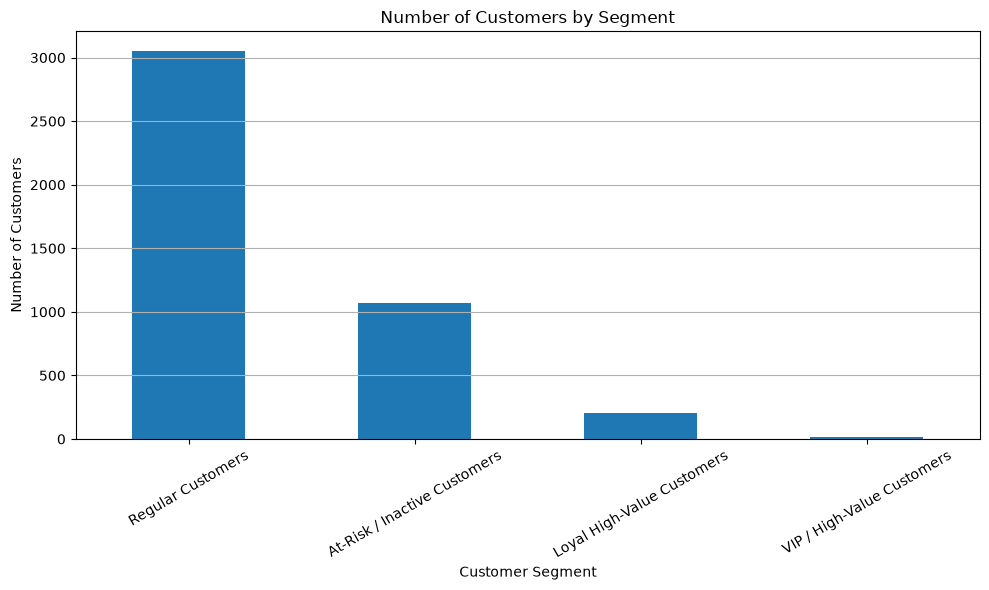

In [34]:
plt.figure(figsize=(10, 6))

segment_counts = segment_summary['Customer_Count'].sort_values(ascending=False)

segment_counts.plot(kind='bar')

plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.tight_layout()

plt.show()